# 02 · Kinds of Outliers

"Outlier" is not one thing. Before choosing a detector you have to decide **which kind** of anomaly you are hunting, because different detectors find different kinds.

- **Global** — far from everything (a $1M transaction).
- **Local** — normal globally, abnormal for its neighbourhood (a normal-sized charge on an account that only ever makes tiny ones).
- **Multivariate** — normal on *every single feature*, abnormal only in combination (an age and an income each plausible, the pair not).

No univariate rule can see the local or multivariate kinds.

In [1]:
%matplotlib inline
import sys
from pathlib import Path

_root = Path.cwd()
while _root != _root.parent and not (_root / "pyproject.toml").exists():
    _root = _root.parent
if str(_root) not in sys.path:
    sys.path.insert(0, str(_root))

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.artifacts import save_figure, save_json

plt.rcParams["figure.dpi"] = 110
SEED = 7

from src.datasets.synthetic import make_dataset, ANOMALY_TYPES
from src.detectors.mahalanobis import MahalanobisDetector

## 1 · One dataset can contain all three

The project's generator plants global, local and multivariate anomalies at known locations. Here they are, colour-coded, in a single dataset.

points by type: {'normal': 552, 'global': 16, 'local': 16, 'multivariate': 16}


PosixPath('/workspaces/outlier_arena/outputs/data/02_taxonomy.json')

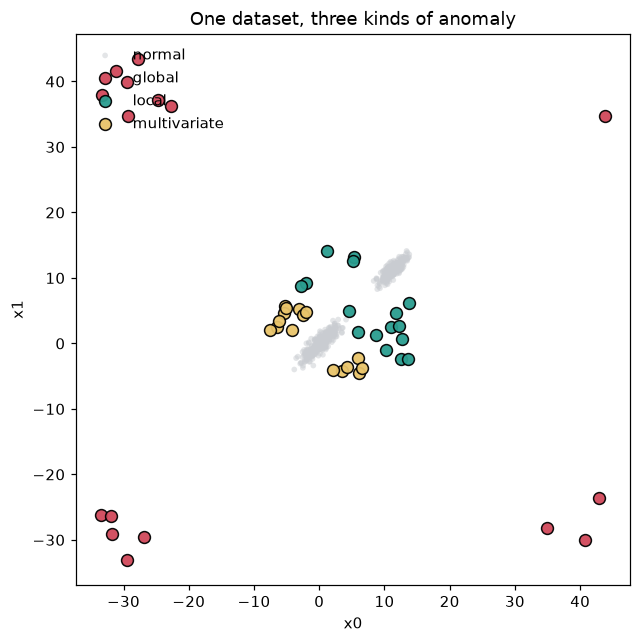

In [2]:
data = make_dataset(n_samples=600, n_features=2, contamination=0.08, seed=SEED)
X, types = data.X, data.types
counts = {t: int((types == t).sum()) for t in ["normal", *ANOMALY_TYPES]}
print("points by type:", counts)

palette = {"normal": "#c9ccd1", "global": "#d1495b",
           "local": "#2a9d8f", "multivariate": "#e9c46a"}
fig, ax = plt.subplots(figsize=(6.5, 6.5))
for t in ["normal", "global", "local", "multivariate"]:
    m = types == t
    ax.scatter(X[m, 0], X[m, 1],
               s=14 if t == "normal" else 60,
               c=palette[t], alpha=0.5 if t == "normal" else 0.95,
               edgecolor="none" if t == "normal" else "k", label=t)
ax.legend(frameon=False, loc="upper left")
ax.set(title="One dataset, three kinds of anomaly", xlabel="x0", ylabel="x1")
save_figure(fig, "02_taxonomy")

save_json({
    "inputs": {"n_samples": 600, "n_features": 2, "contamination": 0.08, "seed": SEED},
    "counts_by_type": counts,
}, "02_taxonomy")

## 2 · The image that makes it undeniable

A **multivariate** outlier is the hardest to argue with once you see it. Below, a point is drawn from neither tail of feature `x0` nor feature `x1` — it is unremarkable on **both** histograms — yet in the scatter it sits far off the correlation the data clearly follows.

(We use a single correlated cloud here so the marginals are a clean single bell; the point is identical in the two-cluster data above.)

point = [1.4, -1.4]
marginal percentiles: x0 at 90%, x1 at 7%  (neither is a 3-sigma tail)
Mahalanobis distance^2 = 27.3, more extreme than 100.0% of the cloud


PosixPath('/workspaces/outlier_arena/outputs/data/02_multivariate.json')

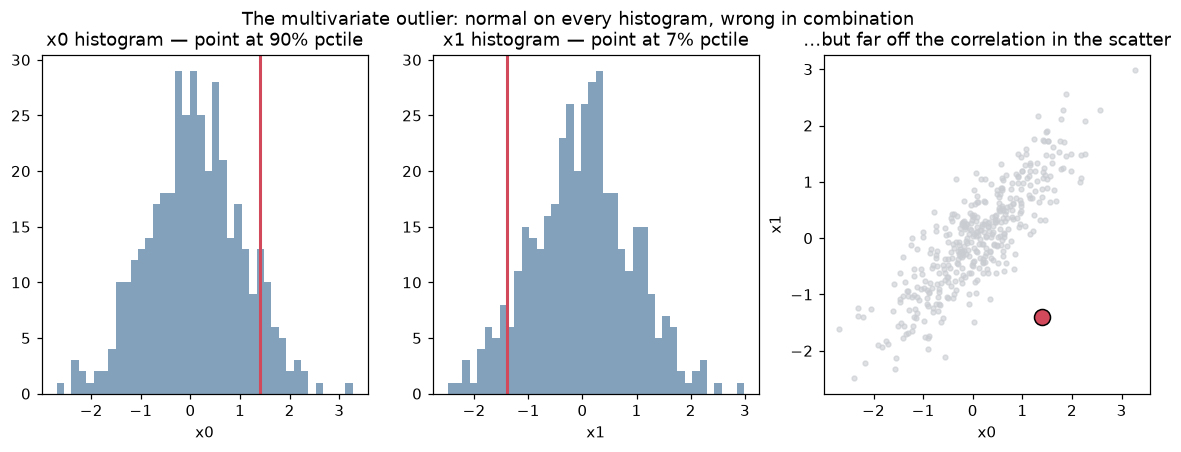

In [3]:
rng = np.random.default_rng(SEED)
cloud = rng.multivariate_normal([0.0, 0.0], [[1.0, 0.85], [0.85, 1.0]], size=400)
mv = np.array([1.4, -1.4])  # plausible on each feature, impossible in combination

pct_x = float((cloud[:, 0] < mv[0]).mean())
pct_y = float((cloud[:, 1] < mv[1]).mean())

maha = MahalanobisDetector()
d2_cloud = maha.mahalanobis_sq(cloud)          # fits mean/precision on the cloud
d2_mv = float(maha.mahalanobis_sq(mv.reshape(1, -1))[0])
maha_rank = float((d2_cloud < d2_mv).mean())    # how extreme vs the cloud

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
axes[0].hist(cloud[:, 0], bins=40, color="#30638e", alpha=0.6)
axes[0].axvline(mv[0], color="#d1495b", lw=2)
axes[0].set(title=f"x0 histogram — point at {pct_x:.0%} pctile", xlabel="x0")
axes[1].hist(cloud[:, 1], bins=40, color="#30638e", alpha=0.6)
axes[1].axvline(mv[1], color="#d1495b", lw=2)
axes[1].set(title=f"x1 histogram — point at {pct_y:.0%} pctile", xlabel="x1")
axes[2].scatter(cloud[:, 0], cloud[:, 1], s=10, c="#c9ccd1", alpha=0.6)
axes[2].scatter([mv[0]], [mv[1]], s=110, c="#d1495b", edgecolor="k", zorder=3)
axes[2].set(title="...but far off the correlation in the scatter", xlabel="x0", ylabel="x1")
fig.suptitle("The multivariate outlier: normal on every histogram, wrong in combination",
             fontsize=12)
save_figure(fig, "02_multivariate_histograms")

print(f"point = {mv.tolist()}")
print(f"marginal percentiles: x0 at {pct_x:.0%}, x1 at {pct_y:.0%}  (neither is a 3-sigma tail)")
print(f"Mahalanobis distance^2 = {d2_mv:.1f}, more extreme than {maha_rank:.1%} of the cloud")

save_json({
    "point": mv.tolist(),
    "marginal_percentiles": {"x0": pct_x, "x1": pct_y},
    "mahalanobis_sq": d2_mv,
    "mahalanobis_more_extreme_than_fraction_of_cloud": maha_rank,
    "note": "plausible on each feature, far off the correlation in combination",
}, "02_multivariate")

## Takeaway

**Name the anomaly before choosing the detector.** A univariate rule reads one feature's histogram at a time; by construction it cannot see the local or multivariate kinds. The next notebook shows which detector catches which kind.

In [4]:
summary = {
    "notebook": "02_kinds_of_outliers",
    "types": list(ANOMALY_TYPES),
    "counts_by_type": counts,
    "multivariate_point": {
        "value": mv.tolist(),
        "marginal_percentiles": {"x0": pct_x, "x1": pct_y},
        "mahalanobis_more_extreme_than_fraction_of_cloud": maha_rank,
    },
    "claim": ("A single dataset can hold global, local and multivariate anomalies; "
              "univariate rules can only ever see the global kind."),
}
save_json(summary, "02_summary")
summary

{'notebook': '02_kinds_of_outliers',
 'types': ['global', 'local', 'multivariate'],
 'counts_by_type': {'normal': 552,
  'global': 16,
  'local': 16,
  'multivariate': 16},
 'multivariate_point': {'value': [1.4, -1.4],
  'marginal_percentiles': {'x0': 0.9025, 'x1': 0.07},
  'mahalanobis_more_extreme_than_fraction_of_cloud': 1.0},
 'claim': 'A single dataset can hold global, local and multivariate anomalies; univariate rules can only ever see the global kind.'}